# Imports

In [1]:
# Core
import os
import numpy as np
import random
import shutil

# Torch essentials
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor
import torch.nn.functional as F

from sklearn.model_selection import train_test_split


# Metrics & evaluation
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# For device configuration
from torchsummary import summary


# Loading the Dataset

In [2]:
root_path = "/kaggle/input/realwaste"
for root, dirs, files in os.walk(root_path):
    print("ROOT:", root)
    print("DIRS:", dirs[:10])  # first 10 subfolders
    print("FILES:", files[:10])
    print("-"*50)


ROOT: /kaggle/input/realwaste
DIRS: ['realwaste-main']
FILES: []
--------------------------------------------------
ROOT: /kaggle/input/realwaste/realwaste-main
DIRS: ['RealWaste']
FILES: ['README.md']
--------------------------------------------------
ROOT: /kaggle/input/realwaste/realwaste-main/RealWaste
DIRS: ['Metal', 'Glass', 'Paper', 'Vegetation', 'Cardboard', 'Textile Trash', 'Food Organics', 'Plastic', 'Miscellaneous Trash']
FILES: []
--------------------------------------------------
ROOT: /kaggle/input/realwaste/realwaste-main/RealWaste/Metal
DIRS: []
FILES: ['Metal_670.jpg', 'Metal_408.jpg', 'Metal_222.jpg', 'Metal_200.jpg', 'Metal_533.jpg', 'Metal_7.jpg', 'Metal_285.jpg', 'Metal_210.jpg', 'Metal_243.jpg', 'Metal_590.jpg']
--------------------------------------------------
ROOT: /kaggle/input/realwaste/realwaste-main/RealWaste/Glass
DIRS: []
FILES: ['Glass_399.jpg', 'Glass_95.jpg', 'Glass_184.jpg', 'Glass_34.jpg', 'Glass_156.jpg', 'Glass_346.jpg', 'Glass_45.jpg', 'Glass_223.

# EDA

Class distribution in TRAIN set:
Cardboard: 323 images
Food Organics: 288 images
Glass: 294 images
Metal: 553 images
Miscellaneous Trash: 346 images
Paper: 350 images
Plastic: 645 images
Textile Trash: 222 images
Vegetation: 305 images


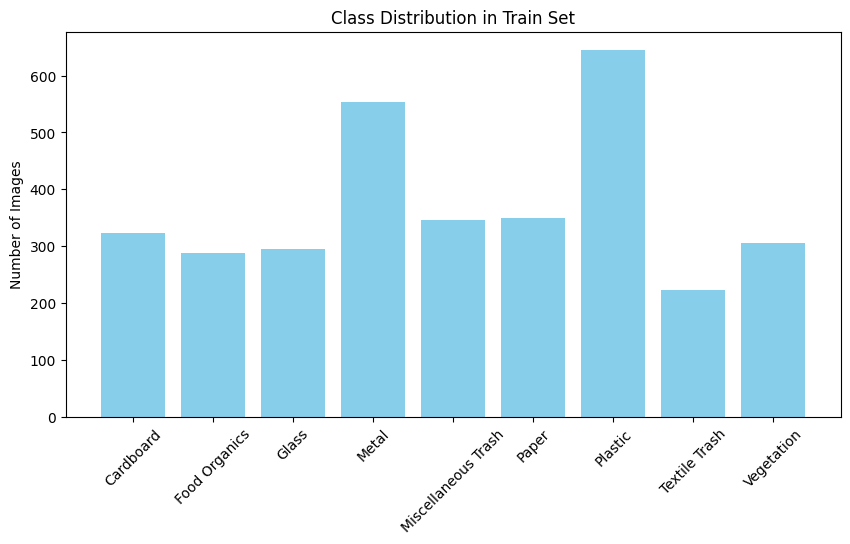

In [51]:
from collections import Counter

# Get class indices for train set only
train_labels = [full_dataset.samples[i][1] for i in train_idx]  # only training indices
class_counts = Counter(train_labels)

# Map counts to class names
class_names = full_dataset.classes
counts = [class_counts[i] for i in range(len(class_names))]

# Print counts
print("Class distribution in TRAIN set:")
for cls, count in zip(class_names, counts):
    print(f"{cls}: {count} images")

# Plot distribution
plt.figure(figsize=(10,5))
plt.bar(class_names, counts, color="skyblue")
plt.xticks(rotation=45)
plt.ylabel("Number of Images")
plt.title("Class Distribution in Train Set")
plt.show()


# Data Augmentation

In [11]:


# Moderate augmentation for training set
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),       # resize consistently
    transforms.RandomHorizontalFlip(p=0.5),   # 50% chance flip
    transforms.RandomRotation(10),       # smaller rotation
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

# Validation & Test: no augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])


# Dataset Split

In [7]:

# Get all targets (class labels) from dataset
full_dataset = datasets.ImageFolder(root=dataset_root, transform=train_transform)
targets = np.array([s[1] for s in full_dataset.samples])

# Train vs Temp (Val+Test)
train_idx, temp_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.30,
    stratify=targets,
    random_state=42
)

# Split Temp into Val and Test (50/50 → 15% each)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=targets[temp_idx],
    random_state=42
)


# Data Loaders

In [12]:


dataset_root = "/kaggle/input/realwaste/realwaste-main/RealWaste"

# Train dataset with augmentation
train_dataset = datasets.ImageFolder(root=dataset_root, transform=train_transform)
train_set = Subset(train_dataset, train_idx)

# Validation & Test datasets without augmentation
val_dataset = datasets.ImageFolder(root=dataset_root, transform=val_test_transform)
val_set = Subset(val_dataset, val_idx)

test_dataset = datasets.ImageFolder(root=dataset_root, transform=val_test_transform)
test_set = Subset(test_dataset, test_idx)


In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=32, shuffle=False)


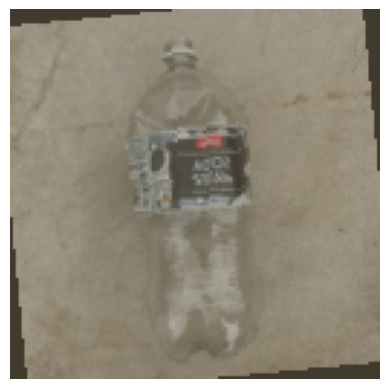

Class: Plastic


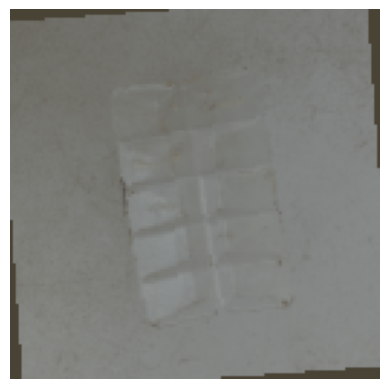

Class: Plastic


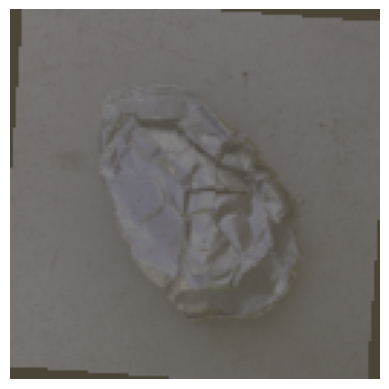

Class: Metal


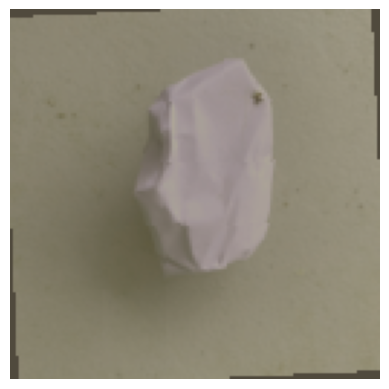

Class: Paper


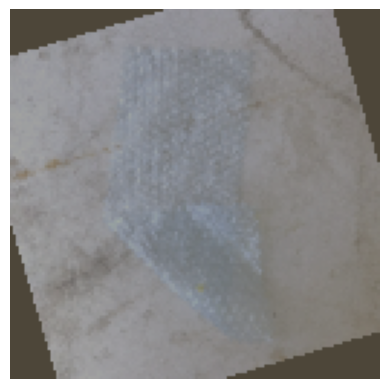

Class: Plastic


In [18]:


# Function to unnormalize and show images
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean  # unnormalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# Show a few augmented images
images, labels = next(iter(train_loader))
for i in range(5):
    imshow(images[i])
    print("Class:", train_dataset.classes[labels[i]])


# Model

In [17]:
import torch.nn as nn
import torch.nn.functional as F

class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=9):
        super(ImprovedCNN, self).__init__()

        # Convolutional layers with BatchNorm
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)   # 128 -> 128
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)  # 128 -> 128
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)                # size /2 each time

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1) # 64 -> 64
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)# 64 -> 64
        self.bn4 = nn.BatchNorm2d(256)

        # Dropout
        self.dropout = nn.Dropout(0.4)

        # Fully connected layers
        # Input: 128x128 -> pool -> 64 -> pool -> 32 -> pool -> 16
        self.fc1 = nn.Linear(256 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Block 2
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = F.relu(self.bn4(self.conv4(x)))

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


# Training with Adam Optimizer 

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes=9).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Cosine Annealing with Warm Restarts
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=5,     # first restart after 5 epochs
    T_mult=2,  # cycle length doubles each restart
    eta_min=1e-6
)

# Tracking variables
train_losses, val_losses = [], []
epochs = 20

for epoch in range(epochs):
    # ---- Training ----
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    # ---- Validation ----
    model.eval()
    val_loss = 0.0
    num_batches = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            num_batches += 1

    val_loss /= num_batches
    val_losses.append(val_loss)

    # ---- Scheduler Step ----
    scheduler.step(epoch + val_loss)   # allow fractional epoch progress
    # ---- Logging ----
    lr = scheduler.get_last_lr()[0]
    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {train_loss:.4f}, "
          f"Val Loss: {val_loss:.4f}, "
          f"LR: {lr:.6f}")





Epoch [1/20], Train Loss: 1.8958, Val Loss: 1.6143, LR: 0.000764
Epoch [2/20], Train Loss: 1.5472, Val Loss: 1.3222, LR: 0.000556
Epoch [3/20], Train Loss: 1.3922, Val Loss: 1.2849, LR: 0.000264
Epoch [4/20], Train Loss: 1.2838, Val Loss: 1.1668, LR: 0.000068
Epoch [5/20], Train Loss: 1.2193, Val Loss: 1.1333, LR: 0.001000
Epoch [6/20], Train Loss: 1.2910, Val Loss: 1.2003, LR: 0.000965
Epoch [7/20], Train Loss: 1.2313, Val Loss: 1.0672, LR: 0.000898
Epoch [8/20], Train Loss: 1.1401, Val Loss: 1.0356, LR: 0.000790
Epoch [9/20], Train Loss: 1.0945, Val Loss: 1.0591, LR: 0.000646
Epoch [10/20], Train Loss: 1.0454, Val Loss: 0.9296, LR: 0.000512
Epoch [11/20], Train Loss: 0.9681, Val Loss: 0.8879, LR: 0.000363
Epoch [12/20], Train Loss: 0.9256, Val Loss: 0.8368, LR: 0.000228
Epoch [13/20], Train Loss: 0.8675, Val Loss: 0.8460, LR: 0.000111
Epoch [14/20], Train Loss: 0.8404, Val Loss: 0.8060, LR: 0.000036
Epoch [15/20], Train Loss: 0.8277, Val Loss: 0.7961, LR: 0.000002
Epoch [16/20], Trai

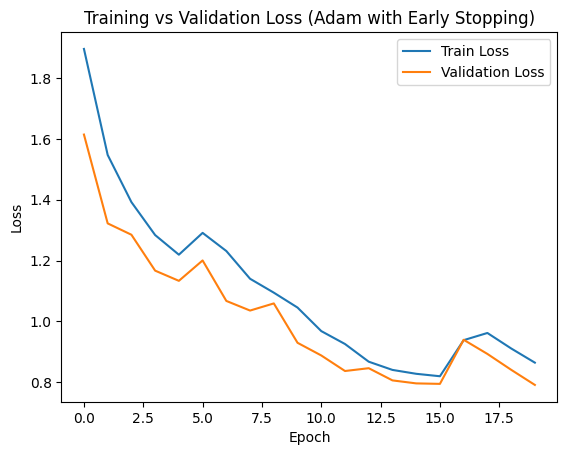

In [19]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss (Adam with Early Stopping)")
plt.show()

# Training with SGD

Epoch [1/20], Train Loss: 2.1409, Val Loss: 2.0392
Epoch [2/20], Train Loss: 1.9183, Val Loss: 1.7655
Epoch [3/20], Train Loss: 1.7562, Val Loss: 1.6616
Epoch [4/20], Train Loss: 1.6205, Val Loss: 1.5455
Epoch [5/20], Train Loss: 1.5671, Val Loss: 1.3755
Epoch [6/20], Train Loss: 1.4541, Val Loss: 1.2748
Epoch [7/20], Train Loss: 1.4222, Val Loss: 1.2664
Epoch [8/20], Train Loss: 1.3921, Val Loss: 1.2919
Epoch [9/20], Train Loss: 1.3681, Val Loss: 1.2713
Epoch [10/20], Train Loss: 1.3421, Val Loss: 1.1326
Epoch [11/20], Train Loss: 1.2590, Val Loss: 1.2110
Epoch [12/20], Train Loss: 1.2099, Val Loss: 1.0794
Epoch [13/20], Train Loss: 1.1467, Val Loss: 0.9787
Epoch [14/20], Train Loss: 1.1183, Val Loss: 1.0727
Epoch [15/20], Train Loss: 1.0488, Val Loss: 1.0170
Epoch [16/20], Train Loss: 1.0688, Val Loss: 1.0306
Epoch [17/20], Train Loss: 1.0302, Val Loss: 0.9838
Epoch [18/20], Train Loss: 0.9929, Val Loss: 0.9656
Epoch [19/20], Train Loss: 0.9670, Val Loss: 0.9200
Epoch [20/20], Train 

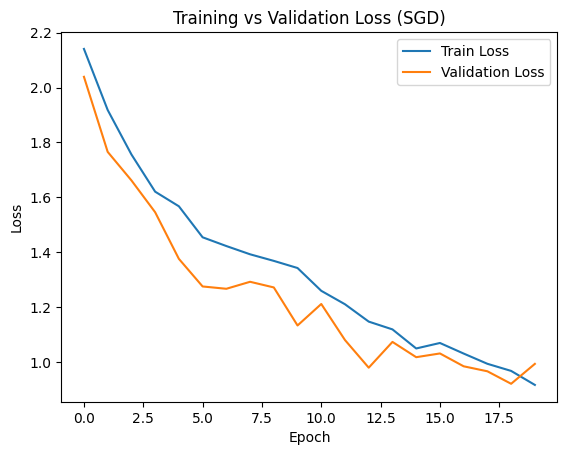

In [20]:
model = SimpleCNN(num_classes=9).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

train_losses, val_losses = [], []

epochs = 20
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Plot losses
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss (SGD)")
plt.show()


# Evaluation

In [21]:
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_labels, all_preds

In [22]:
train_labels, train_preds = evaluate_model(model, train_loader, device)
train_acc = accuracy_score(train_labels, train_preds)
print(f"Train Accuracy: {train_acc:.4f}")


test_labels, test_preds = evaluate_model(model, test_loader, device)
test_acc = accuracy_score(test_labels, test_preds)
print(f" Test Accuracy: {test_acc:.4f}")

precision = precision_score(test_labels, test_preds, average='macro')
recall = recall_score(test_labels, test_preds, average='macro')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Train Accuracy: 0.7492
 Test Accuracy: 0.6550
Precision: 0.6719
Recall: 0.6386


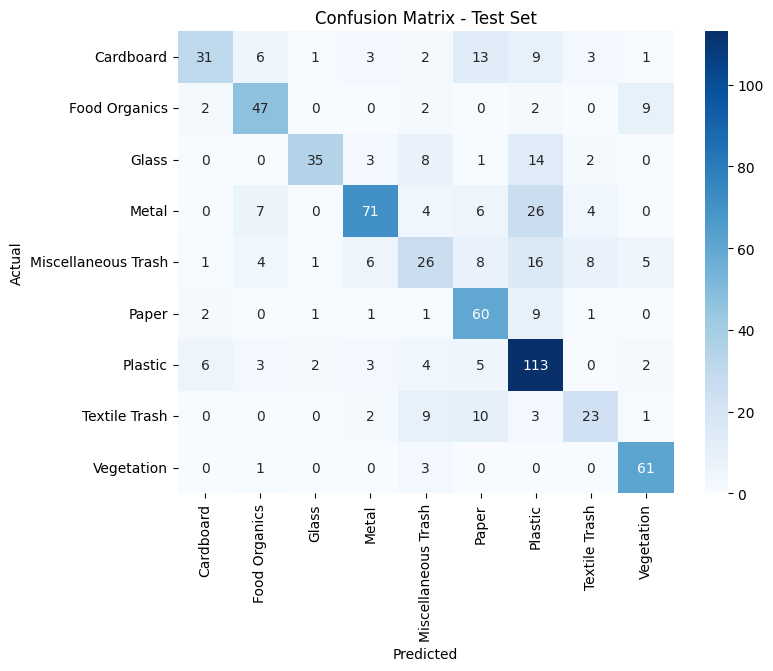

In [23]:
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()